# Segmented Histogram & Segmented Density: Overlapping vs. Contained

Symbulate's **segmented histogram** (`type="segmented_hist"`) and **segmented
density** (`type="segmented_density"`) plots are for *mixed* data — one discrete
variable and one continuous variable. They draw one small histogram / density
curve of the continuous variable per level of the discrete variable, each rising
from its own baseline and stacked along the discrete axis (a ridgeline plot).

This notebook compares two ways of scaling those little plots:

- **Overlapping style** — the *current default behavior*. Each segment's tallest
  bar / peak reaches **1.6 baseline spacings**, so a tall segment spills past the
  next baseline and overlaps its neighbor. This is deliberate: the gentle overlap
  makes the stack read as one connected picture (the classic ridgeline look).
- **Contained style** — each segment's plot is scaled to **stay entirely within
  its own segment** (peak ≤ 1 baseline spacing), so nothing crosses into a
  neighboring segment.

Both styles use the **same data and the same plot settings**, side by side, so
the only visible difference is the vertical scaling.

In [1]:
%matplotlib inline
import importlib

import numpy as np
import matplotlib.pyplot as plt

from symbulate import *

# The overlap amount is a module-level constant in symbulate.plot:
#   SEGMENTED_HIST_PEAK_SCALE    (default 1.6)
#   SEGMENTED_DENSITY_PEAK_SCALE (default 1.6)
# Each is "the tallest bar/peak height, in units of the spacing between
# neighboring baselines." > 1 overlaps; <= 1 stays contained. The plot
# helpers read these at call time, so temporarily lowering them switches a
# plot from overlapping to contained without changing anything else.
#
# (`symbulate.plot` is imported via importlib because `plot` is also a
# function name in the symbulate namespace.)
splot = importlib.import_module("symbulate.plot")

np.random.seed(2026)  # render identically every run

print("default segmented-hist    peak scale:", splot.SEGMENTED_HIST_PEAK_SCALE)
print("default segmented-density peak scale:", splot.SEGMENTED_DENSITY_PEAK_SCALE)

default segmented-hist    peak scale: 1.6
default segmented-density peak scale: 1.6


## Example data (used for every plot below)

A basketball shooter attempts three three-pointers per game. `made` is the
discrete number of makes (0–3); `score` is that game's continuous scoring
margin — about 3 points per make, plus noise. `made` is the grouping variable,
`score` is the continuous value whose distribution we segment by level.

In [2]:
P = Binomial(3, 0.5) * Normal(0, 1)
made = RV(P, lambda outcome: outcome[0])              # discrete: 0, 1, 2, 3
score = RV(P, lambda outcome: 3 * outcome[0] + outcome[1])  # continuous

games = (score & made).sim(2000)
games

0,"(9.04070937622242, 3)"
1,"(2.408811398783229, 1)"
2,"(2.570904864463547, 1)"
3,"(5.508707658528063, 2)"
4,"(9.076585108054779, 3)"
5,"(5.0046989752214746, 2)"
6,"(7.166451210334213, 2)"
7,"(5.331061103374329, 2)"
8,"(3.5710362723285383, 1)"
...,...
1999,"(6.847488085024687, 2)"


## A helper to draw both styles side by side

`compare_styles` draws the **same** `games.plot(...)` call twice on a shared
figure: once with the default (overlapping) peak scale, once with the peak scale
temporarily lowered so each segment is contained. Because it takes the plot type
and keyword arguments once and reuses them for both panels, the two sides are
guaranteed to differ *only* in the overlap scaling.

In [3]:
CONTAINED_SCALE = 0.9  # <= 1 => each segment stays inside its own band


def compare_styles(plot_type, contained_scale=CONTAINED_SCALE, **plot_kwargs):
    """Draw `games.plot(type=plot_type, **plot_kwargs)` overlapping vs. contained."""
    # Share only the value (x) axis so both panels line up horizontally;
    # each keeps its own vertical headroom (the overlapping panel needs more).
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)

    # Left: current default behavior (segments may overlap their neighbors).
    plt.sca(axes[0])
    games.plot(type=plot_type, suggest=False, **plot_kwargs)
    axes[0].set_title("Overlapping (current default)")

    # Right: same call, but peak scale lowered so each segment is contained.
    hist_old = splot.SEGMENTED_HIST_PEAK_SCALE
    dens_old = splot.SEGMENTED_DENSITY_PEAK_SCALE
    splot.SEGMENTED_HIST_PEAK_SCALE = contained_scale
    splot.SEGMENTED_DENSITY_PEAK_SCALE = contained_scale
    try:
        plt.sca(axes[1])
        games.plot(type=plot_type, suggest=False, **plot_kwargs)
        axes[1].set_title("Contained (each stays in its segment)")
    finally:
        # Always restore the defaults, even if plotting raises.
        splot.SEGMENTED_HIST_PEAK_SCALE = hist_old
        splot.SEGMENTED_DENSITY_PEAK_SCALE = dens_old

    fig.tight_layout()
    return fig

## 1. Segmented histogram

`type="segmented_hist"` — one small histogram of `score` per level of `made`.

- **Left (overlapping):** the taller histograms (e.g. levels 2 and 3) rise past
  the next baseline and overlap the row above — the current default.
- **Right (contained):** every histogram is scaled down to fit under the next
  baseline, so no bars enter a neighboring segment.

Same data, same bins, same normalization — only the vertical scaling differs.

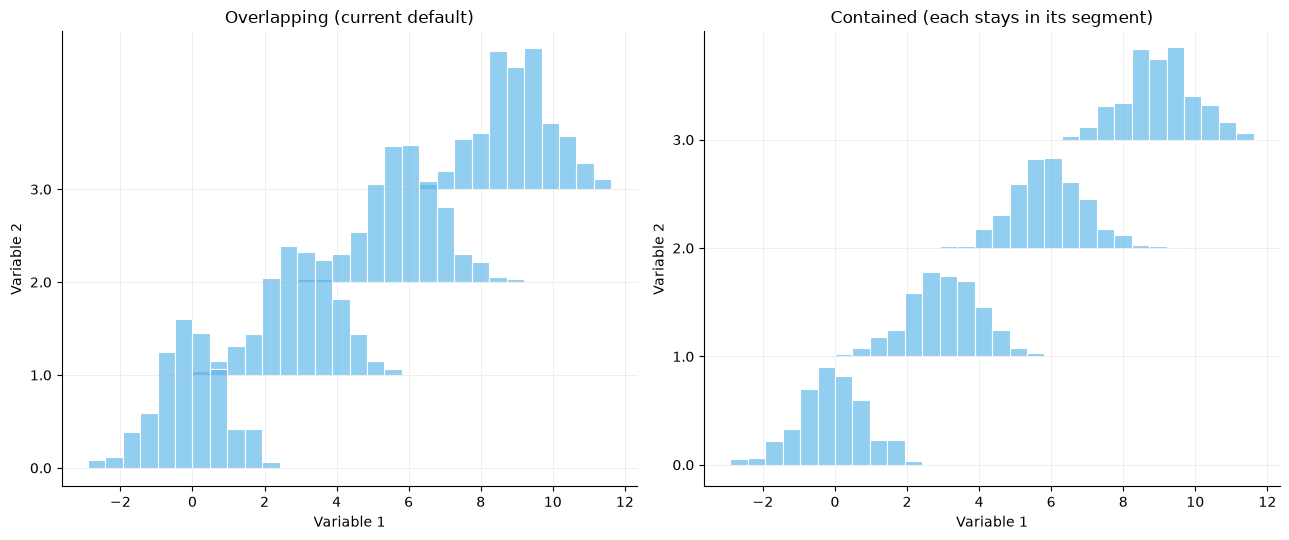

In [4]:
compare_styles("segmented_hist");

## 2. Segmented density

`type="segmented_density"` with `ridge=True` (filled ridgeline curves) — one
smooth density curve of `score` per level of `made`.

- **Left (overlapping):** the filled ridges reach 1.6 baseline spacings and wash
  over the curve below — the connected ridgeline look, and the current default.
- **Right (contained):** each ridge is scaled to sit entirely below the next
  baseline, so the curves never cross into a neighboring segment.

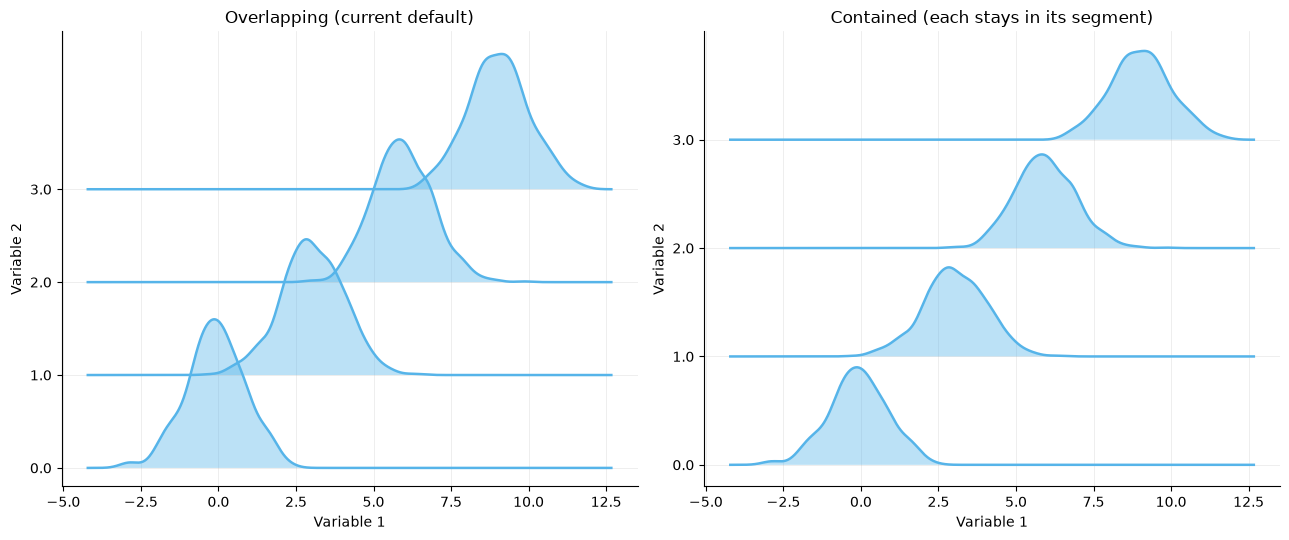

In [5]:
compare_styles("segmented_density", ridge=True);

## Notes

- The **only** thing changed between the two panels is the module constant
  `SEGMENTED_HIST_PEAK_SCALE` / `SEGMENTED_DENSITY_PEAK_SCALE` (1.6 → 0.9). The
  data, bins, bandwidth, colors, baselines, and every other setting are identical.
- Contained scaling trades the connected ridgeline aesthetic for unambiguous
  per-segment reading: each histogram / curve lives strictly inside its own band.
- This is **not currently a user-facing `.plot()` argument** — it's a module
  constant the helpers read at call time. This notebook toggles it in place (and
  restores it) purely to demonstrate the two styles for the team. If we decide the
  contained style is worth exposing, the natural home is a keyword on `.plot()`
  that forwards to the segment helpers.